In [1]:
import pandas as pd
import numpy as np



import sys
sys.path.append('..')

# Loading Data

In [2]:
df_raw = pd.read_parquet(f"../data_in_processing/data_top5std.parquet")

df_raw = df_raw.set_index(["image_T"] + [f"track_id_t{i}" for i in range(5+1)])

df_raw

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

# Selecting every 2th row to speedup tuning HDBSCAN

In [3]:
df = df_raw.iloc[::]

df

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

In [4]:
df.describe()

,ERK_diff_t0,ERK_diff_t1,ERK_diff_t2,ERK_diff_t3,ERK_diff_t4
count,1.738005e+06,1.738005e+06,1.738005e+06,1.738005e+06,1.738005e+06
mean,1.397848e-03,1.306472e-02,2.785558e-02,4.070225e-02,5.680824e-02
std,1.154234e-01,1.670282e-01,2.080534e-01,2.404810e-01,2.946412e-01
min,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,-3.642248e-02,-4.744320e-02,-5.626300e-02,-6.681672e-02,-1.283051e-01
50%,-5.710771e-03,-5.479841e-03,-3.012845e-03,4.113951e-04,2.140109e-03
75%,1.870645e-02,3.378324e-02,7.773499e-02,1.628546e-01,2.916123e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


# Clustering Utilities

In [5]:
from sklearn.cluster import MiniBatchKMeans
import hdbscan

In [37]:
def helper_clustering(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    compression_kmeans = MiniBatchKMeans(
        n_clusters=100_000,
        batch_size=25_600,
    )

    centroid_assigments = compression_kmeans.fit_predict(df.to_numpy())
    centroids = compression_kmeans.cluster_centers_

    return centroid_assigments, centroids

def cluster_centroids(df: pd.DataFrame) -> np.ndarray:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=256,
        min_samples=2,
        core_dist_n_jobs=12
    )

    centroid_assigments, centroids = helper_clustering(df)
    centroid_labels = clusterer.fit_predict(centroids)

    return centroid_labels[centroid_assigments]

def cluster_with_pure_hdbscan(df: pd.DataFrame) -> tuple[np.ndarray, hdbscan.HDBSCAN]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=256,
        min_samples=64,
        core_dist_n_jobs=12,
        cluster_selection_method="leaf",
    )

    return clusterer.fit_predict(df.to_numpy()), clusterer

# Run Clustering

In [38]:
clus_id: int = 5

In [39]:
df["label"], clusterer = cluster_with_pure_hdbscan(df)

In [40]:
df.head(20)

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272                -1.0   
        1264        1316        1300        1264        1300        1272                -1.0   
        1419        1316        1300        1264        1300        1272                -1.0   
        1300        1316        1300        1264        1300        1272                -1.0   
        1019        1316        1300        1264        1300        1272                -1.0   
        1300        1316        1300        762         1300        1272                -1.0   
        1419        1316        1300        762         1300        1272                -1.0   
        1264        1316        1300        762         1300        1272                -1.0   
        762         1316        1300        762         1300        1272                -1.0   
        1019        1316        1300        762         1300        1272                -1.0   
        1419        1316        1300        975         1300        1272                -1.0   
        1019        1316        1300        975         1300        1272                -1.0   
        1300        1316        1300        975         1300        1272                -1.0   
        1264        1316        1300        975         1300        1272                -1.0   
        762         1316        1300        975         1300        1272                -1.0   
                                            1272        1300        1272                -1.0   
        1419        1316        1300        1272        1300        1272                -1.0   
        1019        1316        1300        1272        1300        1272                -1.0   
        1300        1316        1300        1272        1300        1272                -1.0   
        1264        1316        1300        1272        1300        1272                -1.0   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        762         1300        1272            0.786236   
        1419        1316        1300        762         1300        1272            0.786236   
        1264        1316        1300        762         1300        1272            0.786236   
        762         1316        1300        762         1300        1272            0.786236   
        1019        1316        1300        762         1300        1272            0.786236   
        1419        1316        1300        975         1300        1272            0.786236   
        1019        1316        1300        975         1300        1272            0.786236   
        1300        1316        1300        975         1300        1272            0.786236   
        1264        1316        1300        975         1300        1272            0.786236   
        762         1316        1300        975         1300        1272            0.786236   
                                            1272        1300        1272            0.786236   
        1419        1316        1300        1272        1300        1272            0.786236   
        1019        1316        1300        1272        1300        1272            0.786236   
        1300        1316        1300        1272

# Cluster Statistics

In [41]:
from scripts.Scoring_clusters import clustering_coverage_stats, run_scoring

In [42]:
df["label"].value_counts()

label
-1      1652083
 92        4407
 91        2799
 112       1856
 146       1799
         ...   
 132        260
 94         260
 25         260
 90         256
 69         256
Name: count, Length: 168, dtype: int64

In [43]:
len(df["label"].unique())

168

In [44]:
clustering_coverage_stats(df)


    Nodes with Labels:				85922
    Nodes without Labels:			1652083
    Nodes ratio [with label / all]:		85922 / 1738005
    Nodes ratio [with label / all][%]:		4.94%
    Noise [without label / all][%]:		95.06%
    


In [45]:
_ = run_scoring(df)

Davies-Bouldin Score:                   1.051
Calinski-Harabasz Score:                9345.888


# Viewing Stats about Labels

In [46]:
import matplotlib.pyplot as plt

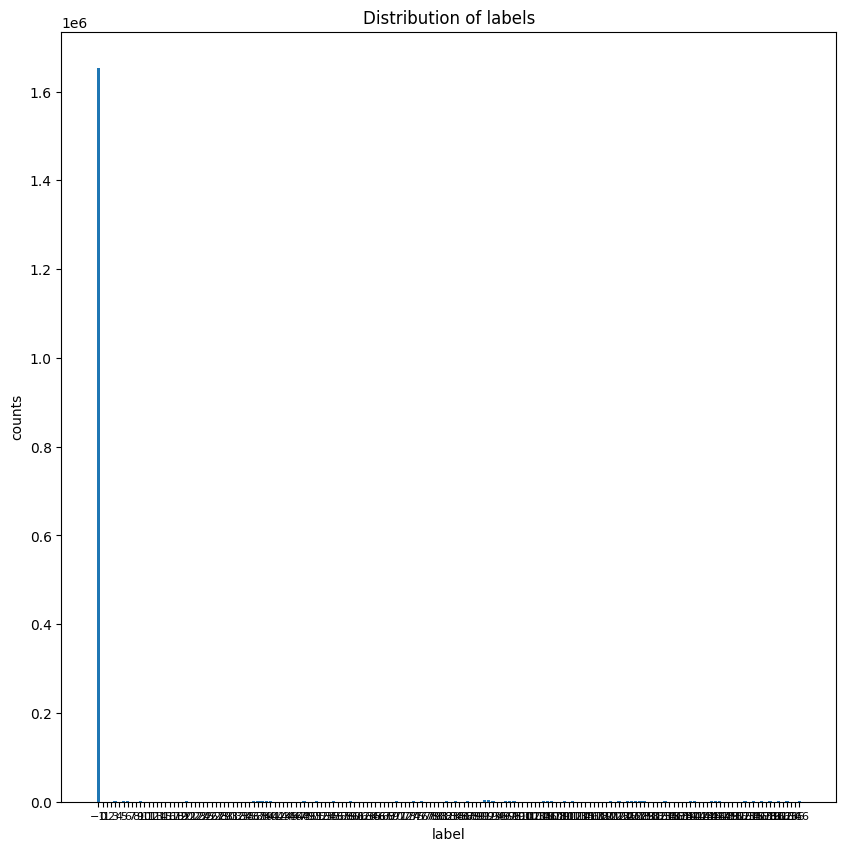

In [47]:
plt.figure(figsize=(10, 10))

plt.bar(df["label"].value_counts().to_dict().keys(), df["label"].value_counts().to_dict().values())

plt.title(f"Distribution of labels")
plt.xlabel(f"label")
plt.ylabel(f"counts")
plt.xticks(list(df["label"].value_counts().to_dict().keys()), fontsize=8)

plt.savefig(f"../outputs/labels_counts_hist.png")

# Saving Labels & Params

In [48]:
import pickle

In [49]:
df.drop(columns=[col for col in df.columns if col not in {"label"}]).to_csv(f"../data_in_processing/cluster_outputs/labels_{clus_id}.csv")

with open(f"../data_in_processing/cluster_outputs/params_{clus_id}.pickle", "wb") as params_f:
    pickle.dump(clusterer.get_params(), params_f)

with open(f"../data_in_processing/cluster_outputs/clusterer_{clus_id}.pickle", "wb") as params_f:
    pickle.dump(clusterer, params_f)